# 02 Exploratory Data Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

In [3]:
df = pd.read_csv("../data/volvo_2020_2024_clean.csv")

df.set_index("Date", inplace=True)
df.index = pd.to_datetime(df.index)
df.head()

,Close,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5
Date,,,,,,,
2020-01-10,106.104263,-0.004783,-0.016928,0.005992,0.008588,-0.022084,107.171765
2020-01-13,105.934288,-0.001602,-0.004783,-0.016928,0.005992,0.008588,106.981384
2020-01-14,106.410225,0.004493,-0.001602,-0.004783,-0.016928,0.005992,106.702608
2020-01-15,106.002266,-0.003834,0.004493,-0.001602,-0.004783,-0.016928,106.213054
2020-01-16,106.852196,0.008018,-0.003834,0.004493,-0.001602,-0.004783,106.260648


### Closing price over time

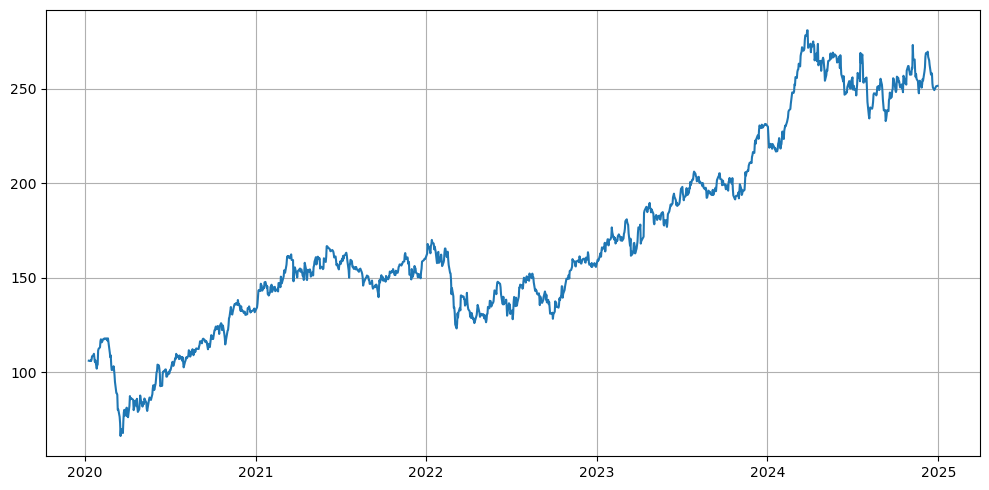

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Close'])
plt.grid(True)
plt.tight_layout()
plt.show()


### Histogram of returns

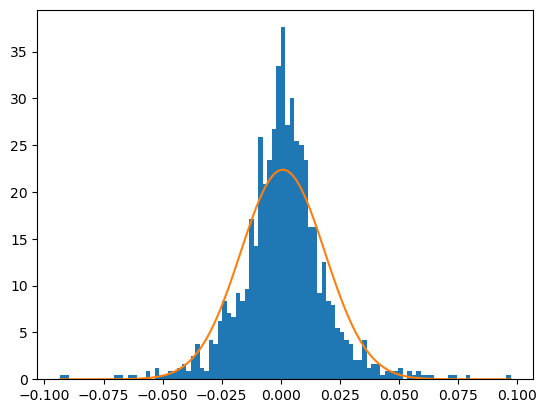

In [5]:
count, bins, ignored = plt.hist(df["Return_Lag_1"], bins=100, density=True)
x = np.linspace(min(bins),max(bins),100)
mean = df["Return_Lag_1"].mean()
std = df["Return_Lag_1"].std()

y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x,y)
plt.show()

### Box-diagram of returns

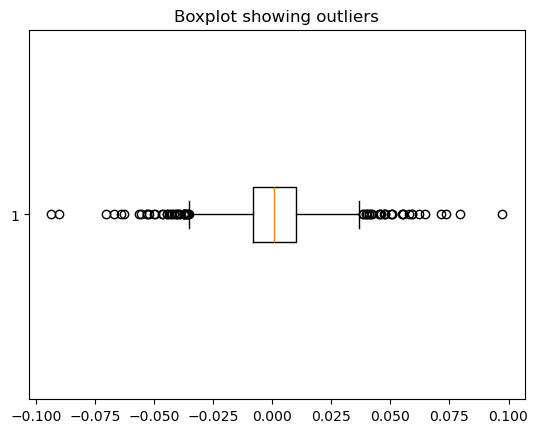

In [6]:
plt.boxplot(df["Return_Lag_1"], vert=False)
plt.title("Boxplot showing outliers")
plt.show()

### Closing price with Moving Average 5 between 2021 and 2022

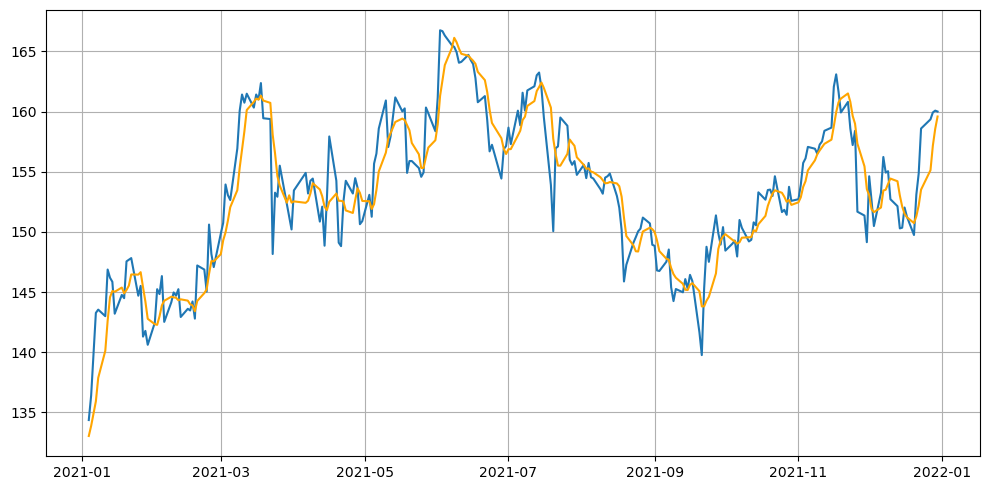

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df.loc['2021-01-01':'2022-01-01'].index, df.loc['2021-01-01':'2022-01-01']['Close'])
plt.plot(df.loc['2021-01-01':'2022-01-01'].index, df.loc['2021-01-01':'2022-01-01']['MA5'], color='orange')
plt.grid(True)
plt.tight_layout()
plt.show()

### Volatility over time (STD)

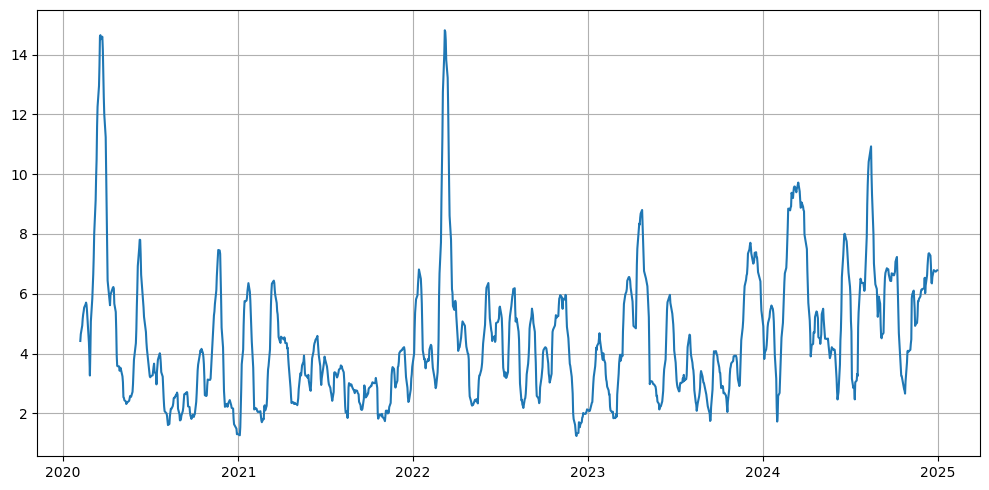

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df["Close"].rolling(20).std())
plt.grid(True)
plt.tight_layout()
plt.show()

### Correlation matrix

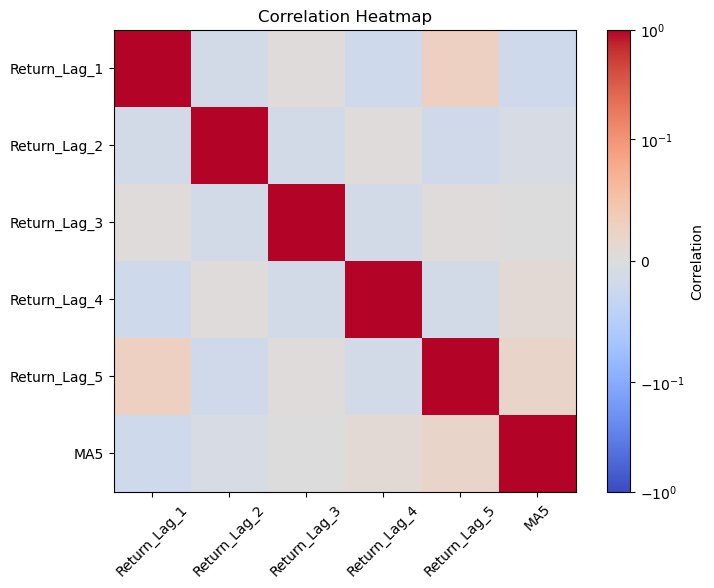

In [9]:
df_corr_matrix = df.filter(items=["Return_Lag_1","Return_Lag_2","Return_Lag_3","Return_Lag_4","Return_Lag_5","MA5"]).corr()

corr_array = df_corr_matrix.to_numpy()

plt.figure(figsize=(8,6))

norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-1, vmax=1)

plt.imshow(corr_array, cmap='coolwarm', norm=norm)
plt.colorbar(label='Correlation')

plt.xticks(ticks=np.arange(len(df_corr_matrix.columns)), labels=df_corr_matrix.columns, rotation=45)
plt.yticks(ticks=np.arange(len(df_corr_matrix.columns)), labels=df_corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

### Autocorrelation plot

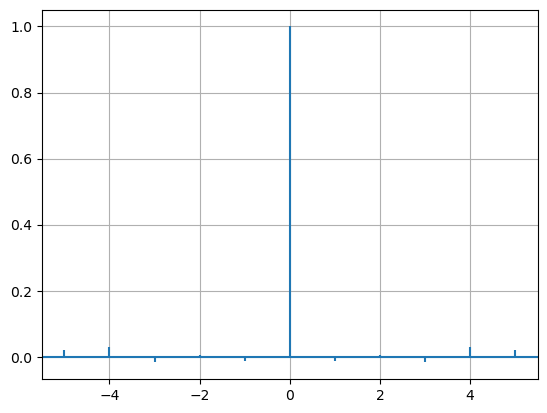

In [10]:
plt.acorr(df["Return_Lag_1"],maxlags = 5)
plt.grid(True)
plt.show()

### Scatterplots

##### Shifting "Close" one day to compare "next day close" to different metrics

In [11]:
df_next_day_close = df

df_next_day_close.reset_index(inplace=True)
df_next_day_close.drop('Date',axis=1,inplace=True)
df_next_day_close["Close"] = df_next_day_close["Close"].shift(-1)
df_next_day_close.dropna(inplace=True)
df_next_day_close.head()



,Close,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5
0,105.934288,-0.004783,-0.016928,0.005992,0.008588,-0.022084,107.171765
1,106.410225,-0.001602,-0.004783,-0.016928,0.005992,0.008588,106.981384
2,106.002266,0.004493,-0.001602,-0.004783,-0.016928,0.005992,106.702608
3,106.852196,-0.003834,0.004493,-0.001602,-0.004783,-0.016928,106.213054
4,108.416054,0.008018,-0.003834,0.004493,-0.001602,-0.004783,106.260648


##### Next day close / Return Lags & MA5

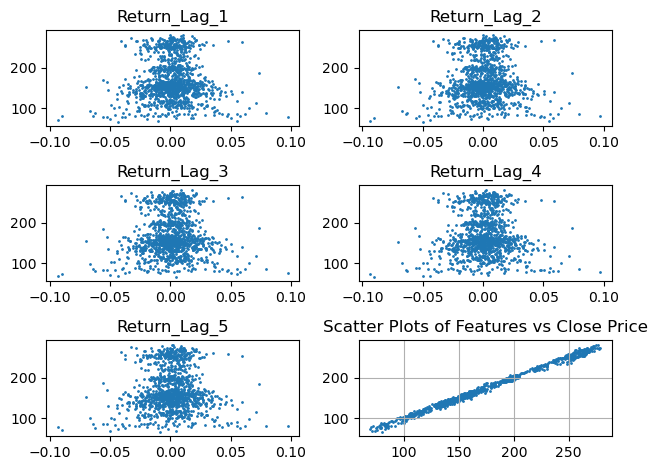

In [ ]:
for i in range(1,6):
    plt.subplot(3,2,i)
    plt.scatter(df_next_day_close[f"Return_Lag_{i}"],df_next_day_close["Close"],s=1)
    plt.title(f"Return_Lag_{i}")


plt.subplot(3,2,6)
plt.scatter(df_next_day_close["MA5"],df_next_day_close["Close"],s=1)
plt.title("MA5")



plt.grid(True)
plt.tight_layout()
plt.show()

